In [ ]:
import networkx as nx

G = nx.read_graphml("./data/Music_Network_Top_Big.graphml")

print(G.number_of_nodes(), G.number_of_edges())
print(type(G))

2189 12197
<class 'networkx.classes.digraph.DiGraph'>


In [ ]:
import warnings

import networkx as nx
import numpy as np
from sklearn.cluster import SpectralClustering


G = G.to_undirected()
G.remove_nodes_from(list(nx.isolates(G)))


USE_LARGEST_COMPONENT = True
if USE_LARGEST_COMPONENT:
    gcc_nodes = max(nx.connected_components(G), key=len)
    G = G.subgraph(gcc_nodes).copy()

nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)

n_clusters = 7


with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
    )
    labels = model.fit_predict(A)

partition = {node: int(label) for node, label in zip(nodes, labels)}

uniq, counts = np.unique(labels, return_counts=True)
print(f"n_nodes={len(nodes)}, n_clusters={n_clusters}")
print("Cluster sizes:", dict(zip(uniq.tolist(), counts.tolist())))
print("Sample (first 15 nodes):", dict(list(partition.items())[:15]))

n_nodes=1386, n_clusters=25
Cluster sizes: {0: 7, 1: 276, 2: 4, 3: 6, 4: 2, 5: 7, 6: 3, 7: 2, 8: 4, 9: 3, 10: 3, 11: 24, 12: 6, 13: 2, 14: 11, 15: 2, 16: 23, 17: 8, 18: 6, 19: 785, 20: 184, 21: 8, 22: 5, 23: 3, 24: 2}
Sample (first 15 nodes): {'Taylor Swift': 19, 'Morgan Wallen': 19, 'Madonna': 19, 'Kenny Chesney': 20, 'Tim McGraw': 19, 'Keith Urban': 19, 'Stevie Wonder': 19, 'Rod Stewart': 1, 'Mariah Carey': 19, 'Jason Aldean': 20, 'Michael Jackson': 19, 'Rascal Flatts': 19, 'Rihanna': 19, 'Billy Joel': 1, 'The Beatles': 19}


In [ ]:
import json
with open("genres.json", "r") as f:
    genre_map = json.load(f)



cluster_json = {}

for node, cluster_id in partition.items():
    cluster_json.setdefault(cluster_id, []).append({
        "artist": node,
        "genres": genre_map.get(node, [])
    })


for cluster_id in cluster_json:
    cluster_json[cluster_id] = sorted(
        cluster_json[cluster_id],
        key=lambda x: x["artist"]
    )

cluster_json

{19: [{'artist': '*NSYNC', 'genres': ['Pop', 'R&B']},
  {'artist': '2 Chainz', 'genres': ['Hip-Hop']},
  {'artist': '2 Unlimited', 'genres': ['Electronic', 'Pop']},
  {'artist': '21 Savage', 'genres': ['Hip-Hop']},
  {'artist': '2Pac', 'genres': ['Hip-Hop']},
  {'artist': '3LW', 'genres': ['Hip-Hop', 'Pop', 'R&B']},
  {'artist': '3OH!3', 'genres': ['Electronic', 'Hip-Hop', 'Pop', 'Rock']},
  {'artist': '3T', 'genres': ['Pop', 'R&B']},
  {'artist': '3rd Bass', 'genres': ['Hip-Hop']},
  {'artist': '50 Cent', 'genres': ['Hip-Hop']},
  {'artist': '504 Boyz', 'genres': ['Hip-Hop']},
  {'artist': '6LACK', 'genres': ['Hip-Hop', 'R&B']},
  {'artist': '6ix9ine', 'genres': ['Hip-Hop']},
  {'artist': 'ABBA', 'genres': ['Pop', 'R&B']},
  {'artist': 'AJR', 'genres': ['Electronic', 'Pop']},
  {'artist': 'ATEEZ', 'genres': ['Electronic', 'Hip-Hop', 'Pop']},
  {'artist': 'AWOLNATION', 'genres': ['Electronic', 'Pop', 'Rock']},
  {'artist': 'Aaliyah', 'genres': ['Hip-Hop', 'Pop', 'R&B']},
  {'artist': '

In [ ]:
import pandas as pd

rows = []

for cluster_id, artists in cluster_json.items():
    for item in artists:
        rows.append({
            "cluster": cluster_id,
            "artist": item["artist"],
            "genres": item["genres"]
        })

df_clusters = pd.DataFrame(rows)

df_clusters

,cluster,artist,genres
0,19,*NSYNC,"[Pop, R&B]"
1,19,2 Chainz,[Hip-Hop]
2,19,2 Unlimited,"[Electronic, Pop]"
3,19,21 Savage,[Hip-Hop]
4,19,2Pac,[Hip-Hop]
...,...,...,...
1381,15,Jim Capaldi,"[Pop, Rock]"
1382,7,Chris Rea,"[Jazz, Pop]"
1383,7,Shirley Bassey,"[Jazz, Pop, R&B]"
1384,24,Buck Owens,[Country]


In [ ]:
for node, label in partition.items():
    G.nodes[node]["spectral_cluster"] = label

nx.write_graphml(G, "spectral_clustered.graphml")

In [ ]:

import os
import networkx as nx


def _primitive(val):
    if val is None:
        return ""
    if isinstance(val, (bool, int, float)):
        return val
    if isinstance(val, str):
        return val
    return str(val)


H = nx.Graph()
for u in G.nodes():
    H.add_node(u, label=str(u), spectral_cluster=int(partition[u]))
for u, v, data in G.edges(data=True):
    attrs = {_primitive(k): _primitive(v) for k, v in (data or {}).items()}
    H.add_edge(u, v, **attrs)

out_dir = "./data"
os.makedirs(out_dir, exist_ok=True)
base = os.path.join(out_dir, "spectral_clusters_gephi")
nx.write_gexf(H, base + ".gexf", encoding="utf-8")
nx.write_graphml(H, base + ".graphml")
print(f"Gephi: File → Open …\n  {os.path.abspath(base + '.gexf')}\n  {os.path.abspath(base + '.graphml')}")

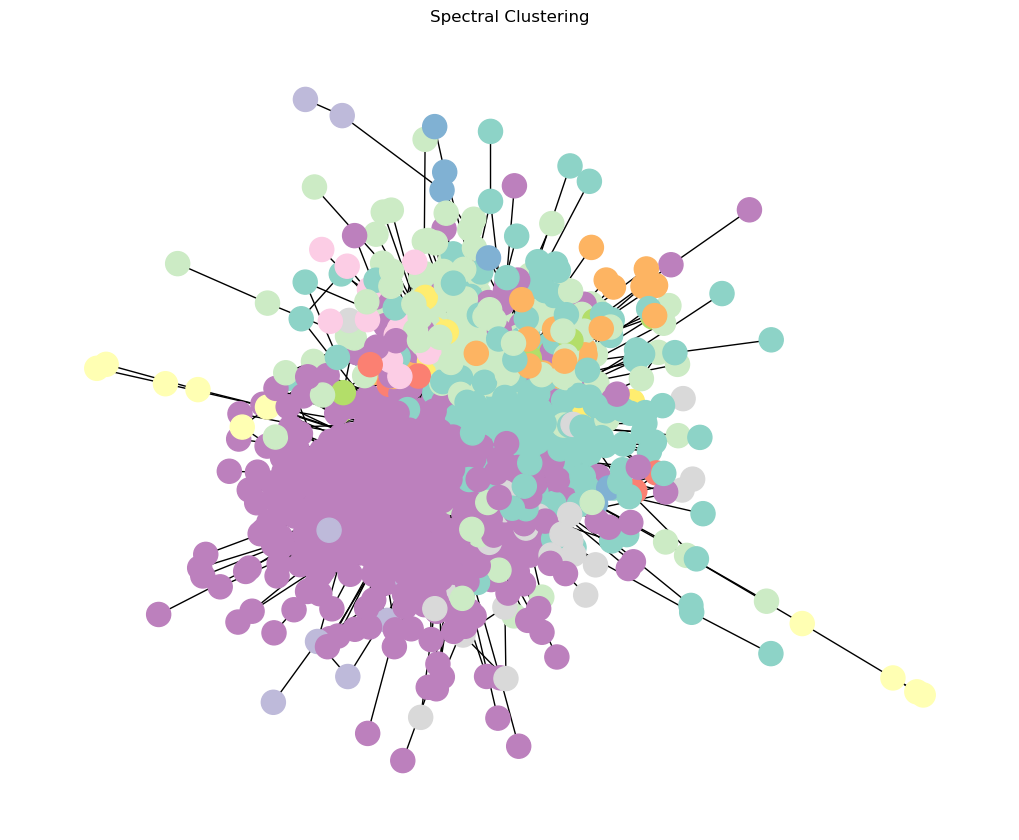

In [ ]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G, seed=42)
node_colors = [partition[node] for node in G.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=False, node_color=node_colors, cmap=plt.cm.Set3)
plt.title("Spectral Clustering")
plt.axis("off")
plt.show()

In [ ]:

import networkx.algorithms.community as nx_comm

A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
k_max = min(10, len(nodes) - 1)
rows = []
for k in range(2, k_max + 1):
    lab = SpectralClustering(
        n_clusters=k,
        affinity="precomputed",
        assign_labels="kmeans",
        random_state=42,
    ).fit_predict(A)
    communities = [set() for _ in range(k)]
    for node, c in zip(nodes, lab):
        communities[c].add(node)
    communities = [c for c in communities if c]
    q = nx_comm.modularity(G, communities)
    rows.append((k, q))

best_k, best_q = max(rows, key=lambda t: t[1])
print("k\tmodularity")
for k, q in rows:
    print(f"{k}\t{q:.4f}")
print(f"\nLargest modularity at k={best_k} (Q={best_q:.4f})")

k	modularity
2	0.0010
3	0.0100
4	0.0153
5	0.0371
6	0.3972
7	0.3965
8	0.4000
9	0.4113
10	0.4170
11	0.4220
12	0.4194
13	0.4358
14	0.4229
15	0.4426
16	0.4326
17	0.4303
18	0.4180
19	0.4228
20	0.4229
21	0.4396
22	0.4434
23	0.4709
24	0.4317
25	0.4201
26	0.4291
27	0.4268
28	0.4659
29	0.4250
30	0.4345
31	0.4370
32	0.4364
33	0.4371
34	0.4382
35	0.4417
36	0.4396
37	0.4429
38	0.4408
39	0.4262
40	0.4834
41	0.4904
42	0.4429
43	0.4257
44	0.4255
45	0.4302
46	0.4215
47	0.4677
48	0.3943
49	0.3189
50	0.4767

Largest modularity at k=41 (Q=0.4904)
